In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Dataset Shape:", X.shape)

Dataset Shape: (569, 30)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


In [4]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred)

print("Baseline Test Accuracy:", baseline_acc)

Baseline Test Accuracy: 0.956140350877193


In [5]:
probs = model.predict_proba(X_train)
confidence = probs.max(axis=1)

In [6]:
prune_sizes = [10, 30, 50, 100, 150]
accuracies = []

for size in prune_sizes:
    idx = np.argsort(confidence)[:size]
    
    X_clean = np.delete(X_train, idx, axis=0)
    y_clean = np.delete(y_train, idx)
    
    model.fit(X_clean, y_clean)
    
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    accuracies.append(acc)

print("Test Accuracies:", accuracies)

Test Accuracies: [0.956140350877193, 0.9736842105263158, 0.9736842105263158, 0.956140350877193, 0.956140350877193]


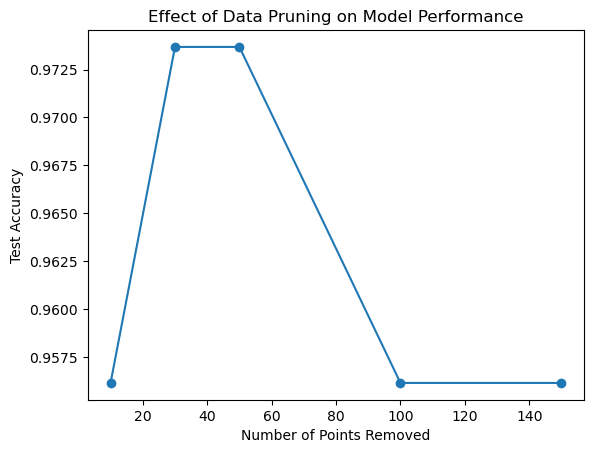

In [7]:
plt.figure()
plt.plot(prune_sizes, accuracies, marker='o')

plt.xlabel("Number of Points Removed")
plt.ylabel("Test Accuracy")
plt.title("Effect of Data Pruning on Model Performance")

plt.savefig("accuracy_vs_pruning.png")
plt.show()

In [8]:
best_index = np.argmax(accuracies)
best_prune = prune_sizes[best_index]
best_acc = accuracies[best_index]

print("Best Pruning Size:", best_prune)
print("Best Test Accuracy:", best_acc)
print("Improvement:", best_acc - baseline_acc)

Best Pruning Size: 30
Best Test Accuracy: 0.9736842105263158
Improvement: 0.01754385964912286


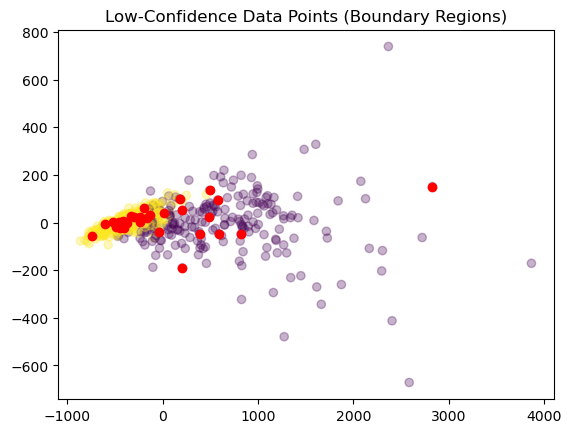

In [9]:
low_idx = np.argsort(confidence)[:best_prune]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, alpha=0.3)

plt.scatter(X_pca[low_idx][:,0],
            X_pca[low_idx][:,1],
            color='red')

plt.title("Low-Confidence Data Points (Boundary Regions)")

plt.savefig("confusing_points_advanced.png")
plt.show()

In [10]:
print("------ FINAL ANALYSIS ------")
print("Baseline Test Accuracy:", baseline_acc)
print("Best Test Accuracy:", best_acc)
print("Improvement:", best_acc - baseline_acc)

------ FINAL ANALYSIS ------
Baseline Test Accuracy: 0.956140350877193
Best Test Accuracy: 0.9736842105263158
Improvement: 0.01754385964912286


In [11]:
from IPython.display import FileLink

FileLink("accuracy_vs_pruning.png")

C:\Users\admin\accuracy_vs_pruning.png

In [12]:
FileLink("confusing_points_advanced.png")

C:\Users\admin\confusing_points_advanced.png